In [1]:
# ==============================================================================
# DEMOSTRACIÓN DE DITHERING EN SEÑALES 1D
# ==============================================================================

import numpy as np
import matplotlib.pyplot as plt
from scipy.fft import fft, fftfreq
from scipy.signal import butter, filtfilt

# Estilo de gráficos
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')

# ------------------------------------------------------------------------------
# 1. PARÁMETROS DE LA SIMULACIÓN
# ------------------------------------------------------------------------------
Fs = 10000          # Frecuencia de muestreo (10 kHz)
duration = 1.0      # Duración en segundos
N = int(Fs * duration)
t = np.linspace(0, duration, N, endpoint=False)

f_sig = 133.0       # Frecuencia de la señal de entrada (Hz)
num_bits = 4        # Cuantización a baja resolución (4 bits = 16 niveles)
V_max = 1.0         # Rango dinámico [-V_max, V_max]

# Tamaño del paso de cuantización (LSB - Least Significant Bit)
levels = 2**num_bits
q_step = (2 * V_max) / levels  # LSB = 2.0 / 16 = 0.125 V

# Señal de entrada: Senoide de baja amplitud (1.2 LSB) para resaltar cuantización
amplitude = 1.2 * q_step
x = amplitude * np.sin(2 * np.pi * f_sig * t)

# ------------------------------------------------------------------------------
# 2. FUNCIONES DE CUANTIZACIÓN Y DITHERING
# ------------------------------------------------------------------------------
def quantize(v, q):
    """Cuantizador uniforme por redondeo al nivel LSB más cercano."""
    return q * np.round(v / q)

def generate_dither(shape, q, dither_type='tpdf'):
    """Genera ruido de dither de tipo RPDF o TPDF."""
    if dither_type == 'rpdf':
        # Rectangular PDF: uniforme en [-q/2, q/2]
        return np.random.uniform(-q/2, q/2, size=shape)
    elif dither_type == 'tpdf':
        # Triangular PDF: suma de dos distribuciones uniformes independientes
        d1 = np.random.uniform(-q/2, q/2, size=shape)
        d2 = np.random.uniform(-q/2, q/2, size=shape)
        return d1 + d2
    elif dither_type == 'gaussian':
        # Gaussian PDF: media 0, desviación estándar q/2
        return np.random.normal(0, q/2, size=shape)
    elif dither_type == 'none':
        return np.zeros(shape)
    else:
        raise ValueError("Tipo de dither no válido.")

# ------------------------------------------------------------------------------
# 3. PROCESAMIENTO DE LAS SEÑALES
# ------------------------------------------------------------------------------
# A) Cuantización SIN dither
x_no_dither = quantize(x, q_step)

# B) Cuantización CON dither TPDF
dither_tpdf = generate_dither(x.shape, q_step, dither_type='gaussian')
x_dithered = quantize(x + dither_tpdf, q_step)

# C) Filtrado paso bajo de la señal con dither para demostrar la recuperación
b, a = butter(4, (f_sig * 2.5) / (Fs / 2), btype='low')
x_dither_filtered = filtfilt(b, a, x_dithered)

# Error de cuantización
err_no_dither = x_no_dither - x
err_dithered = x_dithered - x

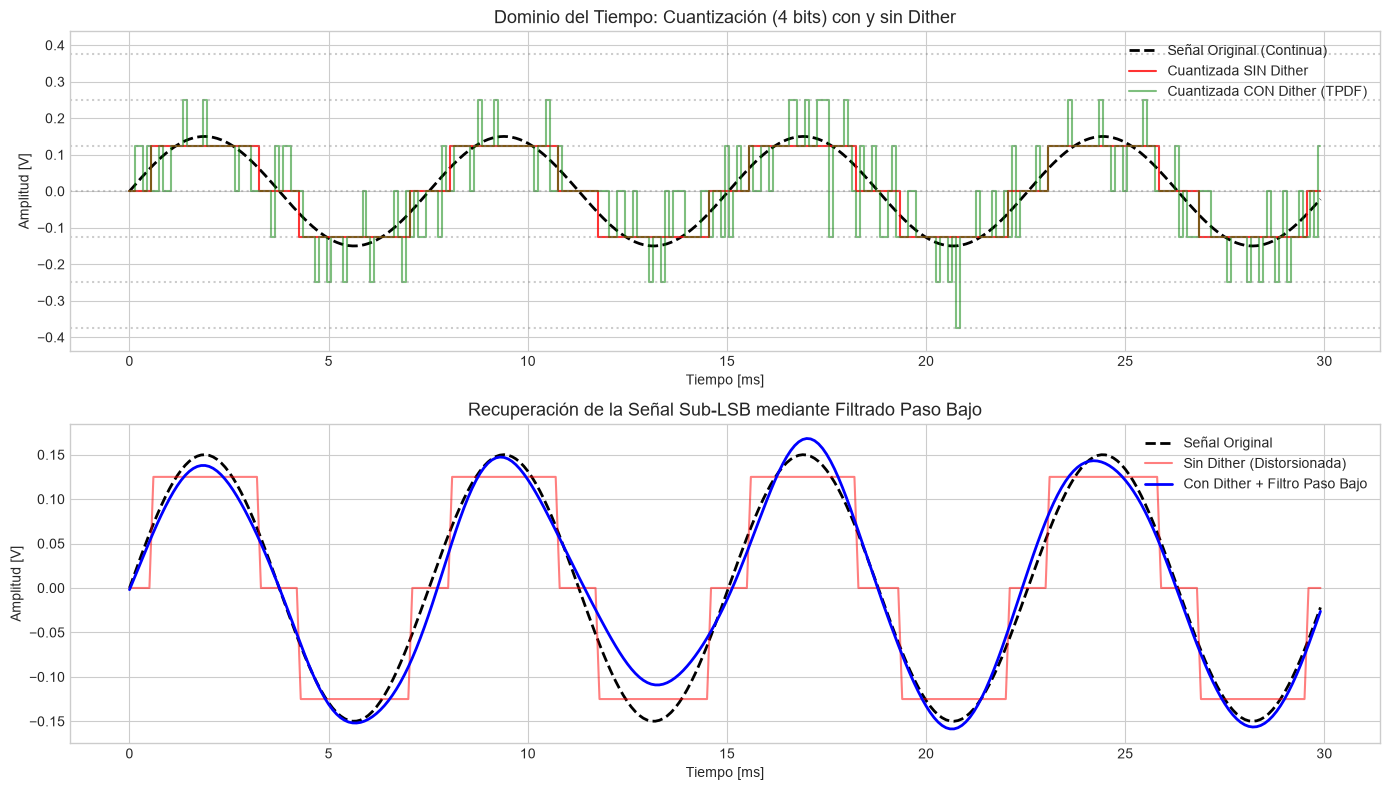

In [2]:
# ==============================================================================
# 4. VISUALIZACIÓN: DOMINIO DEL TIEMPO
# ==============================================================================
plt.figure(figsize=(14, 8))

# Subplot 1: Sin Dither vs Con Dither
plt.subplot(2, 1, 1)
samples_to_show = int(Fs * 0.03)  # Mostrar 30 ms
plt.plot(t[:samples_to_show]*1000, x[:samples_to_show], 'k--', label='Señal Original (Continua)', linewidth=2)
plt.step(t[:samples_to_show]*1000, x_no_dither[:samples_to_show], 'r', where='mid', label='Cuantizada SIN Dither', alpha=0.8)
plt.step(t[:samples_to_show]*1000, x_dithered[:samples_to_show], 'g', where='mid', label='Cuantizada CON Dither (TPDF)', alpha=0.5)

# Dibujar las líneas de los niveles de cuantización
for level in np.arange(-3*q_step, 4*q_step, q_step):
    plt.axhline(level, color='gray', linestyle=':', alpha=0.4)

plt.title('Dominio del Tiempo: Cuantización (4 bits) con y sin Dither', fontsize=13)
plt.xlabel('Tiempo [ms]')
plt.ylabel('Amplitud [V]')
plt.legend(loc='upper right')
plt.ylim(-3.5*q_step, 3.5*q_step)

# Subplot 2: Recuperación de la señal mediante filtrado
plt.subplot(2, 1, 2)
plt.plot(t[:samples_to_show]*1000, x[:samples_to_show], 'k--', label='Señal Original', linewidth=2)
plt.plot(t[:samples_to_show]*1000, x_no_dither[:samples_to_show], 'r', alpha=0.5, label='Sin Dither (Distorsionada)')
plt.plot(t[:samples_to_show]*1000, x_dither_filtered[:samples_to_show], 'b', label='Con Dither + Filtro Paso Bajo', linewidth=2)

plt.title('Recuperación de la Señal Sub-LSB mediante Filtrado Paso Bajo', fontsize=13)
plt.xlabel('Tiempo [ms]')
plt.ylabel('Amplitud [V]')
plt.legend(loc='upper right')

plt.tight_layout()
plt.show()

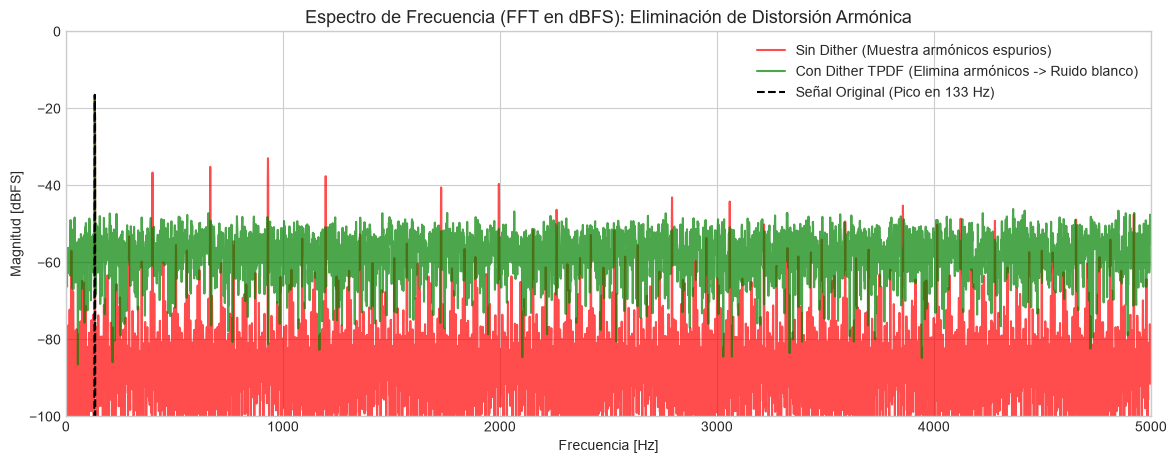

In [8]:
# ==============================================================================
# 5. VISUALIZACIÓN: DOMINIO DE LA FRECUENCIA (FFT / ESPECTRO)
# ==============================================================================
def compute_spectrum_db(signal, Fs):
    """Calcula la magnitud del espectro en dBFS usando una ventana de Hann."""
    N = len(signal)
    win = np.hanning(N)
    win_norm = np.sum(win)
    
    X = fft(signal * win) / win_norm
    freqs = fftfreq(N, 1/Fs)
    
    pos_mask = freqs >= 0
    freqs = freqs[pos_mask]
    X_mag = np.abs(X[pos_mask]) * 2
    
    # Expresar en dBFS (respecto a V_max)
    X_db = 20 * np.log10(X_mag / V_max + 1e-12)
    return freqs, X_db

freqs, spec_orig = compute_spectrum_db(x, Fs)
_, spec_no_dither = compute_spectrum_db(x_no_dither, Fs)
_, spec_dithered = compute_spectrum_db(x_dithered, Fs)

plt.figure(figsize=(14, 5))
plt.plot(freqs, spec_no_dither, 'r', label='Sin Dither (Muestra armónicos espurios)', alpha=0.7)
plt.plot(freqs, spec_dithered, 'g', label='Con Dither TPDF (Elimina armónicos -> Ruido blanco)', alpha=0.7)
plt.plot(freqs, spec_orig, 'k--', label='Señal Original (Pico en 133 Hz)', linewidth=1.5)

plt.title('Espectro de Frecuencia (FFT en dBFS): Eliminación de Distorsión Armónica', fontsize=13)
plt.xlabel('Frecuencia [Hz]')
plt.ylabel('Magnitud [dBFS]')
plt.xlim(0, Fs/2)
plt.ylim(-100, 0)
plt.legend(loc='upper right')
plt.show()

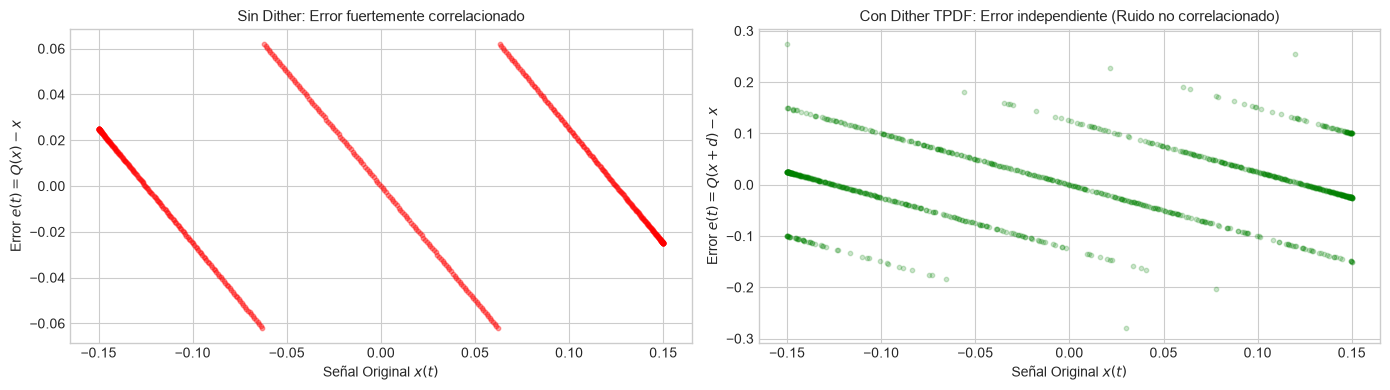

In [4]:
# ==============================================================================
# 6. ANÁLISIS DEL ERROR Y CORRELACIÓN CON LA SEÑAL
# ==============================================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Dispersión Error vs Señal (Sin Dither)
axes[0].scatter(x[::10], err_no_dither[::10], color='red', alpha=0.2, s=10)
axes[0].set_title('Sin Dither: Error fuertemente correlacionado', fontsize=11)
axes[0].set_xlabel('Señal Original $x(t)$')
axes[0].set_ylabel('Error $e(t) = Q(x) - x$')

# Dispersión Error vs Señal (Con Dither)
axes[1].scatter(x[::10], err_dithered[::10], color='green', alpha=0.2, s=10)
axes[1].set_title('Con Dither TPDF: Error independiente (Ruido no correlacionado)', fontsize=11)
axes[1].set_xlabel('Señal Original $x(t)$')
axes[1].set_ylabel('Error $e(t) = Q(x+d) - x$')

plt.tight_layout()
plt.show()